# pyPetrograph — mineral-map grain counter (v0.0.5)

Demo on three Rich Kyle–BEG test maps in `Test images/`: **10A**, **10C**, **10E**, plus `Mineral_Legend.tiff`.

These maps are already painted one solid color per mineral (white = background). The notebook does **not** use the RGB wand/LightGBM pipeline or the PPL/XPL object pipeline. No TensorFlow, no Qt.

Run cells **in order**. Outputs go to `outputs/mineralmap/`.

![Mineral-map workflow](project%20images/workflow.png)

| Setting | What it does |
|---|---|
| `COLOR_TOL = 40` | Pixel belongs to a class if its RGB is within 40 of that legend color. |
| `SPECK_PX = 30` | Blobs smaller than 30 px are absorbed into the neighbor. |
| `UNKNOWN_SPECK_PX = 50` | Extra absorb for Unknown/black blobs up to 50 px. |
| `MIN_GRAIN_PX = 100` | Grains smaller than 100 px are dropped from the saved table. |
| `SPLIT = True` | Cut same-color grains that touch. A color change is always a boundary. |
| `BRIDGE_PX = 4` | Break bridges thinner than ~9 px. |
| `H_MIN = 3` | Cut a thin pinch between two bulky parts. The pinch must be ≥ 3 px closer to the edge than either bulge. |
| `NOTCH_SOLIDITY = 0.85`, `NOTCH_HALVES = 0.88` | V / L / needle cuts; both halves must be compact. `NOTCH_SOLIDITY = 0` turns this off. |
| `UNKNOWN_FRAC = 0.95` | Grain is Unknown only if ≥ 95% of its pixels are Unknown/black. |
| `DISPLAY_RGB` | Overlay-only color overrides (Biotite mid-blue here). |


## Setup

In [1]:
%matplotlib inline

from pathlib import Path
import sys

ROOT = Path(".")
if str(ROOT.resolve()) not in sys.path:
    sys.path.insert(0, str(ROOT.resolve()))

from pyPetrograph import check_and_install_packages
_ = check_and_install_packages(install=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 150
from PIL import Image

from pyPetrograph import (
    set_output_dir,
    read_legend_swatches,
    legend_from_image,
    check_legend,
    process_folder,
    format_counts,
    format_unlisted,
    pivot_counts,
    mineralmap_paths,
)


Package check
----------------------------------------
  numpy                 ok
  PIL                   ok
  matplotlib            ok
  sklearn               ok
  scipy                 ok
  geopandas             ok
  shapely               ok
  rasterio              ok
  affine                ok
  joblib                ok
  pandas                ok
  lightgbm              ok
  skimage               ok
  PyQt5                 ok
----------------------------------------
All required packages are available.


## Settings

In [2]:
set_output_dir("outputs")

IMAGE_DIR = Path("Test images")
LEGEND_PATH = IMAGE_DIR / "Mineral_Legend.tiff"
DEMO_STEMS = ["10A_Mineral_Image", "10C_Mineral_Image", "10E_Mineral_Image"]
IMAGE_PATHS = [IMAGE_DIR / f"{s}.tiff" for s in DEMO_STEMS]

LEGEND = {
    "Monazite & Xenotime": (255, 0, 0),
    "Zircon": (0, 255, 255),
    "Rutile": (255, 192, 203),
    "Ilmenite": (0, 100, 0),
    "Iron Oxides": (128, 0, 0),
    "Biotite": (0, 0, 85),
    "Quartz": (255, 255, 0),
    "Chromite": (255, 0, 255),
    "Orthoclase": (255, 165, 0),
    "Carpholite": (205, 92, 92),
    "Garnet-Spessartine": (106, 90, 205),
    "Pseudobrookite": (0, 255, 0),
    "Illite": (184, 134, 11),
    "Calderite": (227, 92, 28),
    "Topaz": (148, 0, 211),
    "Tourmaline": (65, 105, 225),
    "Unknown": (0, 0, 0),
}

# Or build LEGEND from the swatch image (names must match swatches top to bottom):
# LEGEND = legend_from_image(LEGEND_PATH, names=[
#     "Monazite & Xenotime", "Zircon", "Rutile", "Ilmenite", "Iron Oxides",
#     "Biotite", "Quartz", "Chromite", "Orthoclase", "Carpholite",
#     "Garnet-Spessartine", "Pseudobrookite", "Illite", "Calderite",
#     "Topaz", "Tourmaline",
# ])

COLOR_TOL = 40
SPECK_PX = 30
UNKNOWN_SPECK_PX = 50
MIN_GRAIN_PX = 100
SPLIT = True
BRIDGE_PX = 4
H_MIN = 3.0
NOTCH_SOLIDITY = 0.85
NOTCH_HALVES = 0.88
UNKNOWN_FRAC = 0.95
DISPLAY_RGB = {"Biotite": (70, 130, 255)}  # overlay only

N_JOBS = 4
LOAD_SAVED = True
WRITE_GEOJSON = True

print(f"{len(IMAGE_PATHS)} images:", [p.stem for p in IMAGE_PATHS])
for p in IMAGE_PATHS:
    if not p.exists():
        raise FileNotFoundError(p)


3 images: ['10A_Mineral_Image', '10C_Mineral_Image', '10E_Mineral_Image']


## 1. Legend check

In [3]:
swatches = read_legend_swatches(LEGEND_PATH)
problems = check_legend(LEGEND, swatches)
if problems:
    print("LEGEND mismatches:")
    for m in problems:
        print("  -", m)
else:
    print(f"LEGEND matches {len(swatches)} swatches in {LEGEND_PATH.name}")


LEGEND matches 16 swatches in Mineral_Legend.tiff


## 2. Run (w/ uncertainty estimate)

Each cell is **grain count ± counting noise [low–high]**.

- The middle number is the count with the settings above.
- ± is typical Poisson scatter (√n).
- [low–high] is the count if you make the smallest kept grain twice as small or twice as large.


In [4]:
all_counts = process_folder(
    IMAGE_PATHS,
    LEGEND,
    n_jobs=N_JOBS,
    load_saved=LOAD_SAVED,
    color_tol=COLOR_TOL,
    speck_px=SPECK_PX,
    unknown_speck_px=UNKNOWN_SPECK_PX,
    min_grain_px=MIN_GRAIN_PX,
    split=SPLIT,
    bridge_px=BRIDGE_PX,
    h_min=H_MIN,
    notch_solidity=NOTCH_SOLIDITY,
    notch_halves=NOTCH_HALVES,
    write_geojson=WRITE_GEOJSON,
    unknown_frac=UNKNOWN_FRAC,
    display_rgb=DISPLAY_RGB,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
display(format_counts(all_counts).reindex(list(LEGEND) + ["TOTAL"]))


image,10A_Mineral_Image,10C_Mineral_Image,10E_Mineral_Image
class,,,
Monazite & Xenotime,1 ± 1 [1–1],8 ± 3 [3–20],138 ± 12 [98–153]
Zircon,0 ± 0 [0–0],1737 ± 42 [1230–1790],1594 ± 40 [1099–1675]
Rutile,9 ± 3 [5–13],328 ± 18 [259–380],903 ± 30 [681–1053]
Ilmenite,0 ± 0 [0–0],11 ± 3 [6–15],152 ± 12 [108–182]
Iron Oxides,0 ± 0 [0–0],5 ± 2 [3–8],67 ± 8 [45–77]
Biotite,0 ± 0 [0–0],0 ± 0 [0–0],0 ± 0 [0–0]
Quartz,3552 ± 60 [2738–3798],340 ± 18 [252–384],326 ± 18 [251–361]
Chromite,53 ± 7 [41–56],0 ± 0 [0–0],2 ± 1 [1–2]
Orthoclase,272 ± 16 [227–298],43 ± 7 [34–48],48 ± 7 [33–56]


## 3. Preview (10A, 10C, 10E)

Left: the original painted map. Right: the same grains colored by the legend class we assigned.

The table under each pair lists map colors that did **not** match any legend color (farther than `COLOR_TOL`). Those pixels were counted as **Unknown**.

| Column | Meaning |
|---|---|
| `map_red`, `map_green`, `map_blue` | That color on the map |
| `pixels` | How many pixels have that color |
| `closest_legend_color` | Nearest name in the legend (still too far to use) |
| `distance_from_legend` | How far that color is from that legend swatch, in RGB units. 0 = exact match. Every row here is greater than `COLOR_TOL` (40). |


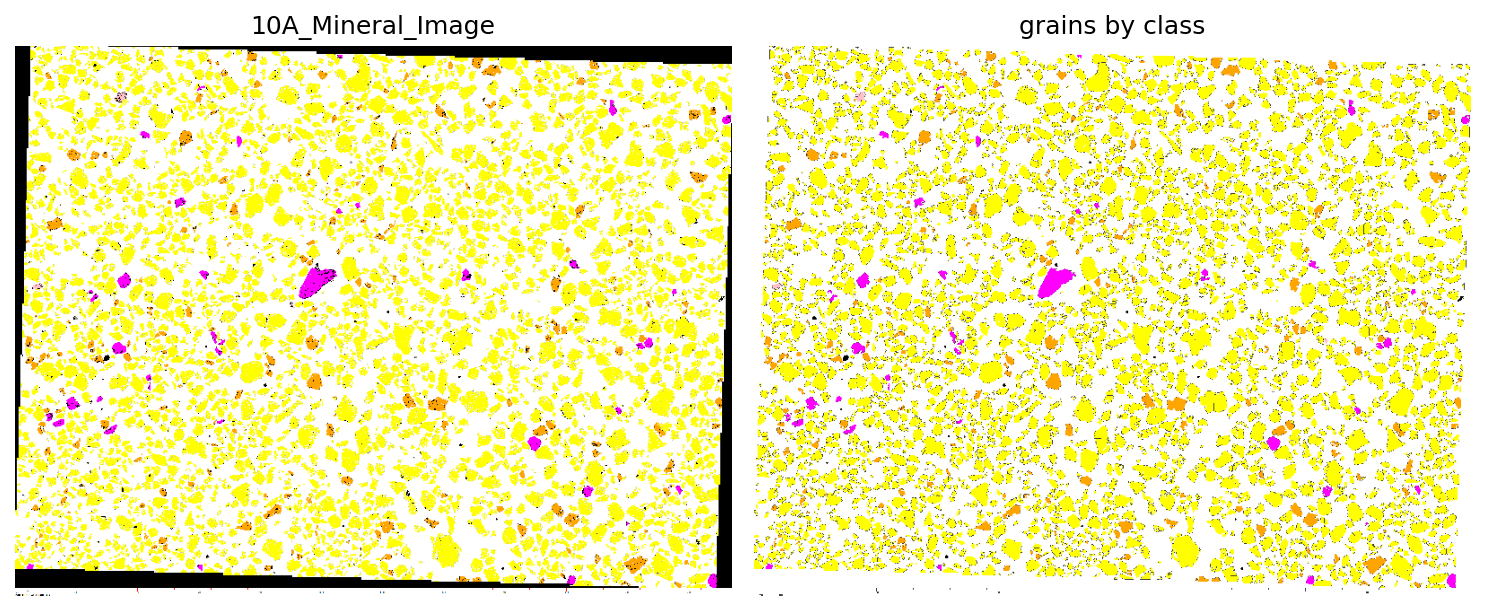

35 map colors in 10A_Mineral_Image were farther than COLOR_TOL=40 from every legend swatch, so they were counted as Unknown.
distance_from_legend = how far that map color is from the closest legend color (RGB units; 0 = exact match).


,map_red,map_green,map_blue,pixels,closest_legend_color,distance_from_legend
0,192,192,192,284580,Rutile,64.0
1,150,150,150,1268,Garnet-Spessartine,92.5
2,191,255,255,396,Rutile,103.8
3,255,99,71,359,Calderite,51.8
4,255,255,191,319,Rutile,64.1
5,255,224,156,316,Rutile,56.9
6,156,224,255,212,Rutile,116.3
7,72,0,116,186,Biotite,78.4
8,224,156,72,158,Carpholite,69.7
9,116,0,72,144,Iron Oxides,73.0


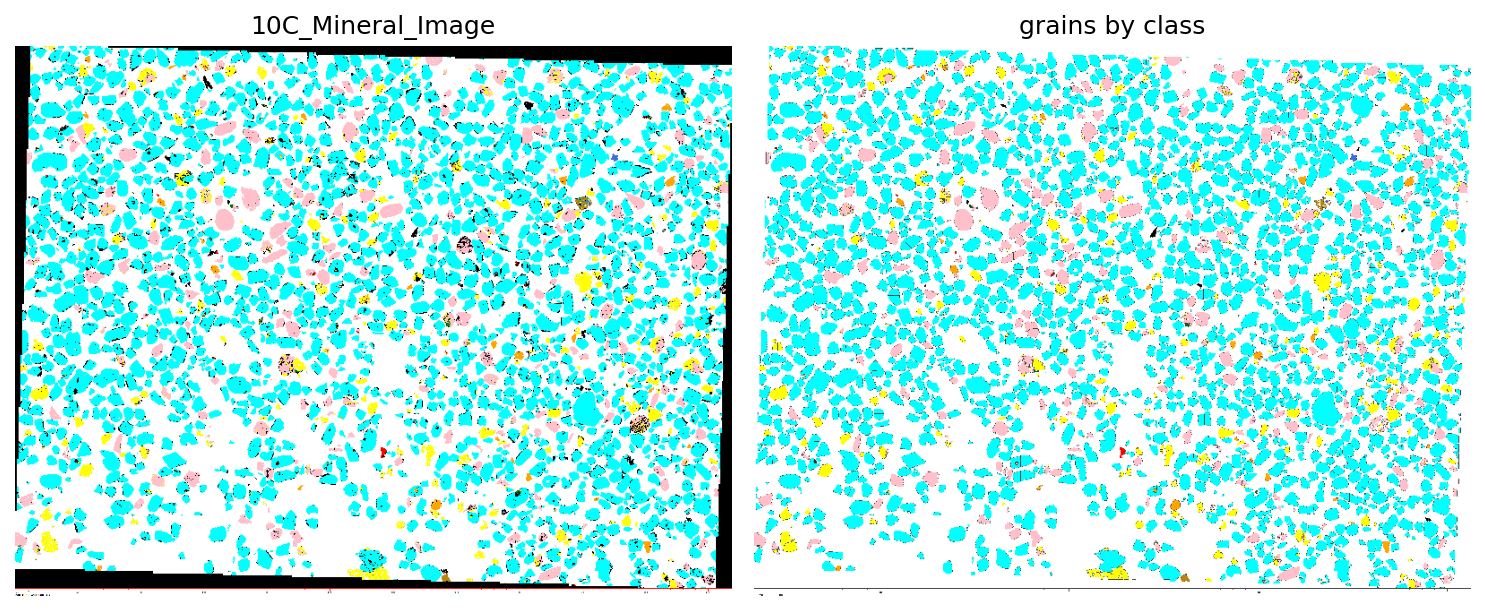

35 map colors in 10C_Mineral_Image were farther than COLOR_TOL=40 from every legend swatch, so they were counted as Unknown.
distance_from_legend = how far that map color is from the closest legend color (RGB units; 0 = exact match).


,map_red,map_green,map_blue,pixels,closest_legend_color,distance_from_legend
0,192,192,192,143837,Rutile,64.0
1,101,157,26,2369,Illite,87.4
2,191,255,255,392,Rutile,103.8
3,255,255,191,322,Rutile,64.1
4,255,224,156,313,Rutile,56.9
5,156,224,255,215,Rutile,116.3
6,72,0,116,180,Biotite,78.4
7,224,156,72,157,Carpholite,69.7
8,116,0,72,144,Iron Oxides,73.0
9,72,156,224,140,Tourmaline,51.5


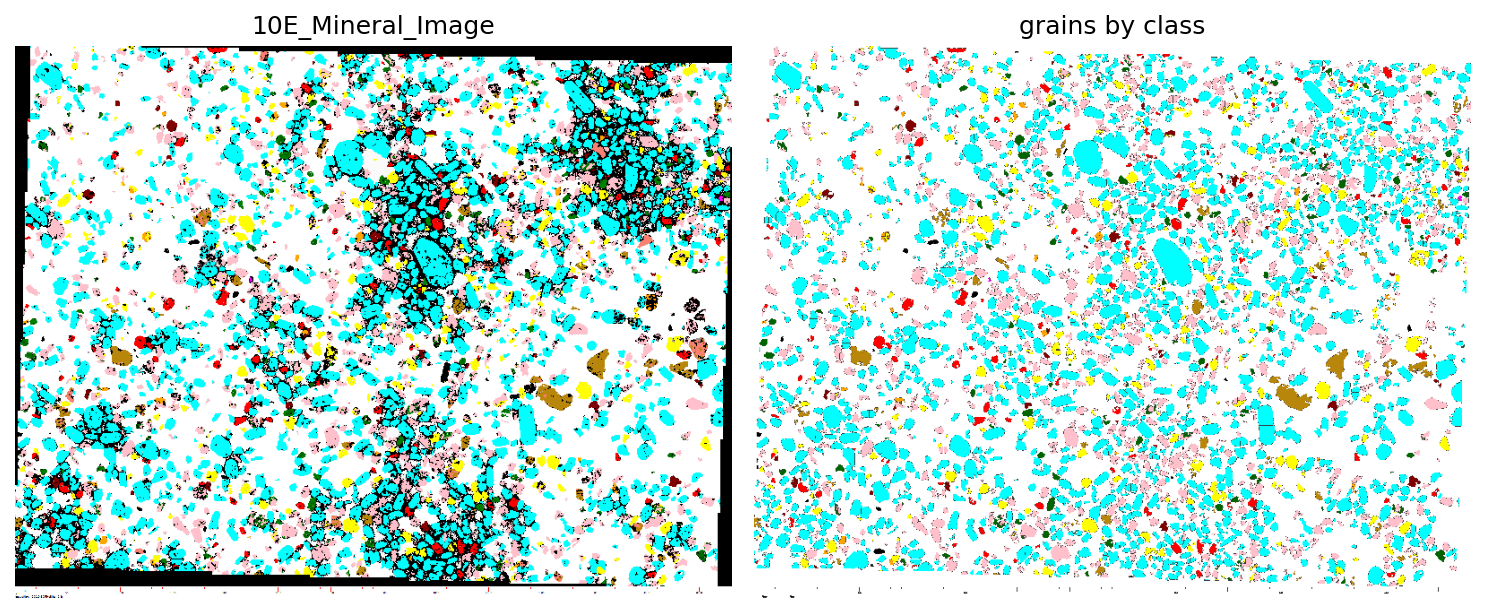

36 map colors in 10E_Mineral_Image were farther than COLOR_TOL=40 from every legend swatch, so they were counted as Unknown.
distance_from_legend = how far that map color is from the closest legend color (RGB units; 0 = exact match).


,map_red,map_green,map_blue,pixels,closest_legend_color,distance_from_legend
0,192,192,192,119538,Rutile,64.0
1,250,128,114,22764,Carpholite,61.7
2,150,150,150,3310,Garnet-Spessartine,92.5
3,191,255,255,444,Rutile,103.8
4,255,255,191,375,Rutile,64.1
5,255,224,156,345,Rutile,56.9
6,156,224,255,246,Rutile,116.3
7,72,0,116,199,Biotite,78.4
8,224,156,72,170,Carpholite,69.7
9,116,0,72,165,Iron Oxides,73.0


In [5]:
for PREVIEW in IMAGE_PATHS:
    paths = mineralmap_paths(PREVIEW)
    if not paths["class_rgb"].exists():
        print("skip preview — missing", paths["class_rgb"])
        continue
    orig = Image.open(PREVIEW).convert("RGB")
    over = Image.open(paths["class_rgb"])
    scale = 800 / max(orig.size)
    size = (int(orig.size[0] * scale), int(orig.size[1] * scale))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), dpi=150)
    axes[0].imshow(orig.resize(size, Image.NEAREST)); axes[0].set_title(PREVIEW.stem)
    axes[1].imshow(over.resize(size, Image.NEAREST)); axes[1].set_title("grains by class")
    for ax in axes:
        ax.set_axis_off()
    plt.tight_layout(); plt.show()

    unlisted = format_unlisted(pd.read_csv(paths["unlisted_csv"]))
    print(
        f"{len(unlisted)} map colors in {PREVIEW.stem} were farther than COLOR_TOL={COLOR_TOL} "
        "from every legend swatch, so they were counted as Unknown."
    )
    print("distance_from_legend = how far that map color is from the closest legend color (RGB units; 0 = exact match).")
    display(unlisted.head(15))


## 4. Share of grains

Stacked bars: percent of grains in each mineral class (including Unknown). The table under the chart is the raw grain counts.


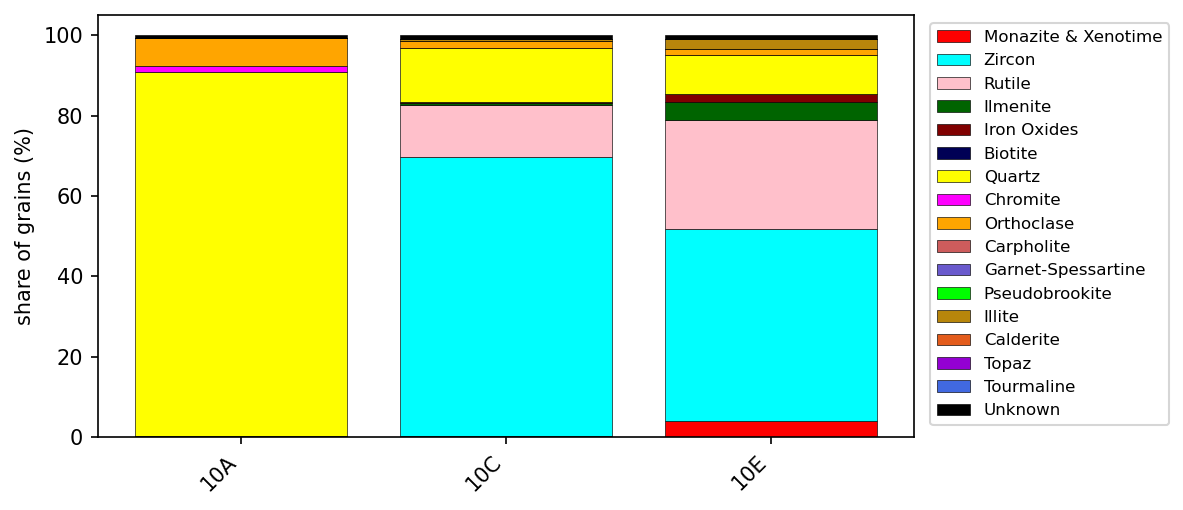

,10A,10C,10E
class,,,
Monazite & Xenotime,1,8,138
Zircon,0,1737,1594
Rutile,9,328,903
Ilmenite,0,11,152
Iron Oxides,0,5,67
Biotite,0,0,0
Quartz,3552,340,326
Chromite,53,0,2
Orthoclase,272,43,48


In [6]:
share = pivot_counts(all_counts[all_counts["class"] != "TOTAL"], "share_pct").fillna(0.0)
share = share.reindex(list(LEGEND)).fillna(0.0)
colors = [tuple(v / 255 for v in LEGEND.get(c, (128, 128, 128))) for c in share.index]

fig, ax = plt.subplots(figsize=(8, 3.5), dpi=150)
bottom = np.zeros(share.shape[1])
for (cls, row), col in zip(share.iterrows(), colors):
    ax.bar(share.columns, row.to_numpy(), bottom=bottom, color=col, edgecolor="k", linewidth=0.3, label=cls)
    bottom += row.to_numpy()
ax.set_ylabel("share of grains (%)")
ax.set_xticks(range(share.shape[1]))
ax.set_xticklabels([c.replace("_Mineral_Image", "") for c in share.columns], rotation=45, ha="right")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

counts_n = pivot_counts(all_counts, "n").reindex(list(LEGEND) + ["TOTAL"])
counts_n.columns = [c.replace("_Mineral_Image", "") for c in counts_n.columns]
display(counts_n.astype("Int64"))
